# Problem Statement

The problem addressed in this project is to analyze the data on Amazon Prime Movies and TV Shows to reveal important patterns, trends, and insights. This includes combining multiple datasets, cleaning and preparing the data, and conducting exploratory data analysis to understand factors like content type distribution, genre popularity, rating patterns, and timing trends.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving credits.csv.zip to credits.csv.zip
Saving titles.csv.zip to titles.csv.zip


In [ ]:
import pandas as pd

# load datasets
# dataset 1 - credits.csv.zip
# dataset 2 - titles.csv.zip
df1 = pd.read_csv("credits.csv.zip")
df2 = pd.read_csv("titles.csv.zip")

# dataset preview
print("Dataset 1 Shape:", df1.shape)
print("Dataset 2 Shape:", df2.shape)

print("\nDataset 1 Columns:\n", df1.columns)
print("\nDataset 2 Columns:\n", df2.columns)

print("\nDataset 1 Preview:")
print(df1.head())

print("\nDataset 2 Preview:")
print(df2.head())


# merging credits.csv & titles.csv
merged_df = pd.merge(df1, df2, on='id', how='left')

print("\nMerged Dataset Shape:", merged_df.shape)

print("\nMerged Dataset Preview:")
print(merged_df.head())


# dataset overview
print("\nMerged Dataset Info:")
print(merged_df.info())

print("\nSummary Statistics:")
print(merged_df.describe())

Dataset 1 Shape: (124235, 5)
Dataset 2 Shape: (9871, 15)

Dataset 1 Columns:
 Index(['person_id', 'id', 'name', 'character', 'role'], dtype='object')

Dataset 2 Columns:
 Index(['id', 'title', 'type', 'description', 'release_year',
       'age_certification', 'runtime', 'genres', 'production_countries',
       'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity',
       'tmdb_score'],
      dtype='object')

Dataset 1 Preview:
   person_id       id           name      character   role
0      59401  ts20945     Joe Besser            Joe  ACTOR
1      31460  ts20945     Moe Howard            Moe  ACTOR
2      31461  ts20945     Larry Fine          Larry  ACTOR
3      21174  tm19248  Buster Keaton    Johnny Gray  ACTOR
4      28713  tm19248    Marion Mack  Annabelle Lee  ACTOR

Dataset 2 Preview:
        id                        title   type  \
0  ts20945            The Three Stooges   SHOW   
1  tm19248                  The General  MOVIE   
2  tm82253  The Best Years of O

In [ ]:
import pandas as pd
import ast


# keep one row per movie/show (Removing Duplicates)
merged_df = merged_df.drop_duplicates(subset=['id'])

print("Shape after removing duplicates:", merged_df.shape)

# handling missing values
# numeric columns → fill with mean
num_cols = ['imdb_score', 'imdb_votes', 'tmdb_popularity', 'tmdb_score']

for col in num_cols:
    if col in merged_df.columns:
        merged_df[col] = merged_df[col].fillna(merged_df[col].mean())

# categorical columns → fill with "Unknown"
cat_cols = ['age_certification', 'character', 'description']

for col in cat_cols:
    if col in merged_df.columns:
        merged_df[col] = merged_df[col].fillna("Unknown")

# seasons → fill with 0
if 'seasons' in merged_df.columns:
    merged_df['seasons'] = merged_df['seasons'].fillna(0)

# imdb_id
merged_df['imdb_id'] = merged_df['imdb_id'].fillna("Unknown")
merged_df['genres'] = merged_df['genres'].apply(ast.literal_eval)

# output
print("\nFinal Shape:", merged_df.shape)
print("\nMissing values:\n", merged_df.isnull().sum())

Shape after removing duplicates: (8861, 19)

Final Shape: (8861, 19)

Missing values:
 person_id               0
id                      0
name                    0
character               0
role                    0
title                   0
type                    0
description             0
release_year            0
age_certification       0
runtime                 0
genres                  0
production_countries    0
seasons                 0
imdb_id                 0
imdb_score              0
imdb_votes              0
tmdb_popularity         0
tmdb_score              0
dtype: int64


In [ ]:
import numpy as np

# create two groups and mean calculation
old_movies = merged_df[merged_df['release_year'] < 2000]['imdb_score']
new_movies = merged_df[merged_df['release_year'] >= 2000]['imdb_score']

mean_old = np.mean(old_movies)
mean_new = np.mean(new_movies)

print("Mean IMDb (Before 2000):", mean_old)
print("Mean IMDb (After 2000):", mean_new)

# difference
difference = mean_new - mean_old
print("Difference in means:", difference)

Mean IMDb (Before 2000): 5.895053403597804
Mean IMDb (After 2000): 5.948420617545492
Difference in means: 0.05336721394768773


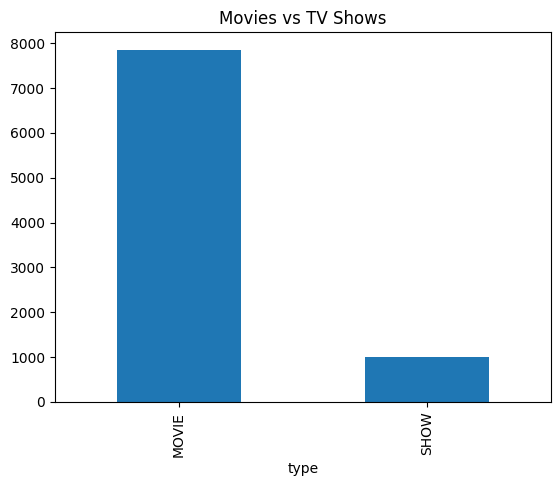

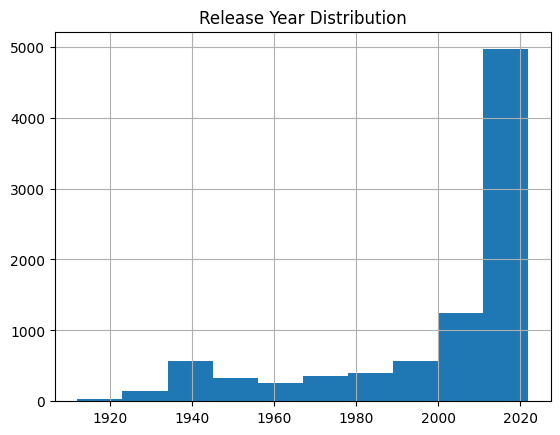

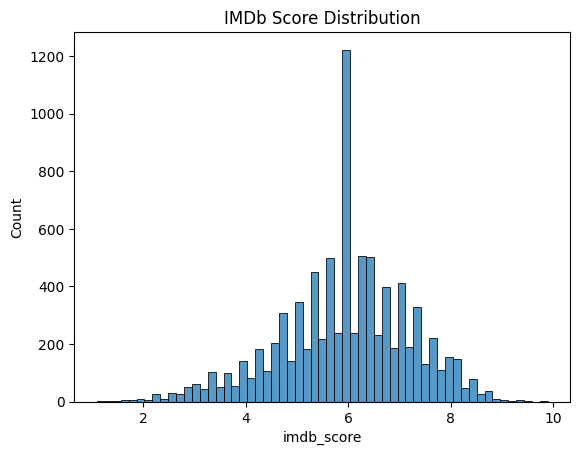

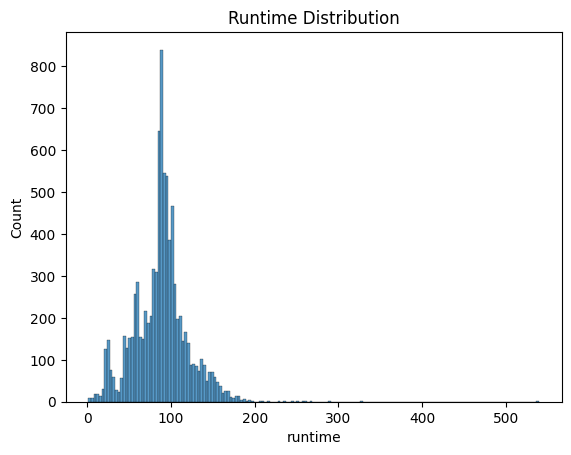

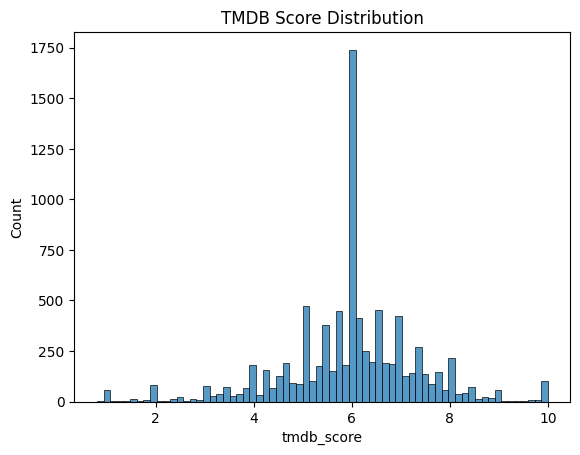

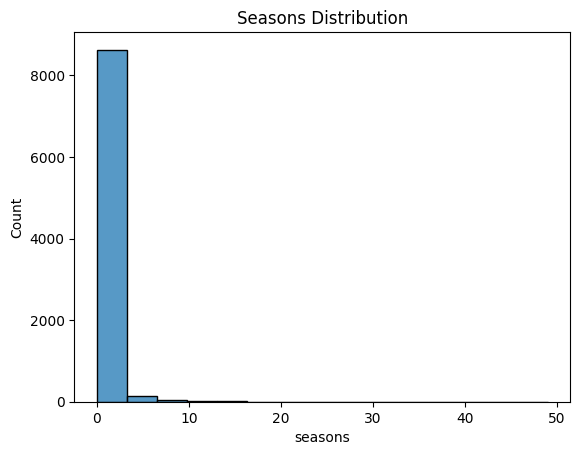

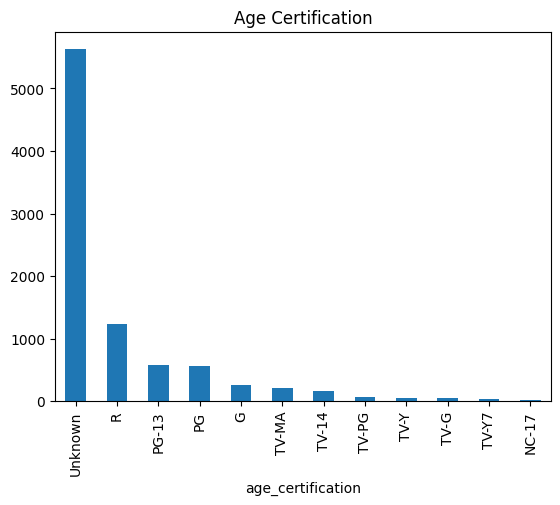

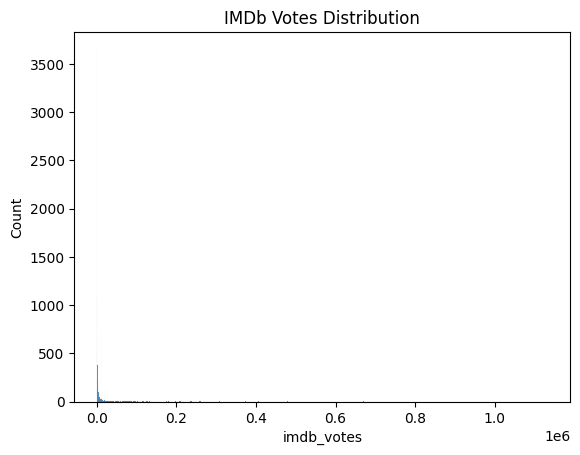

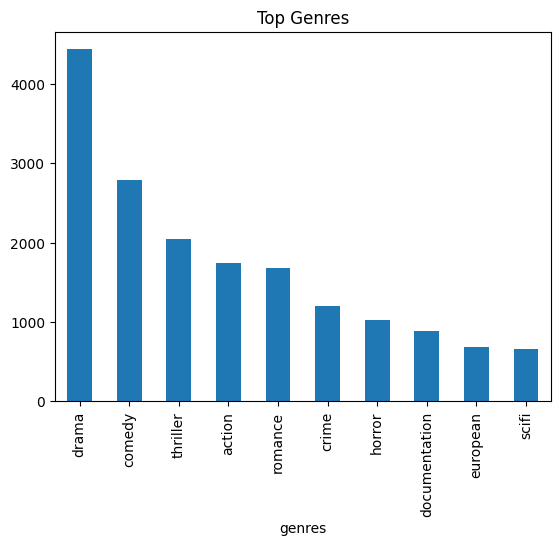

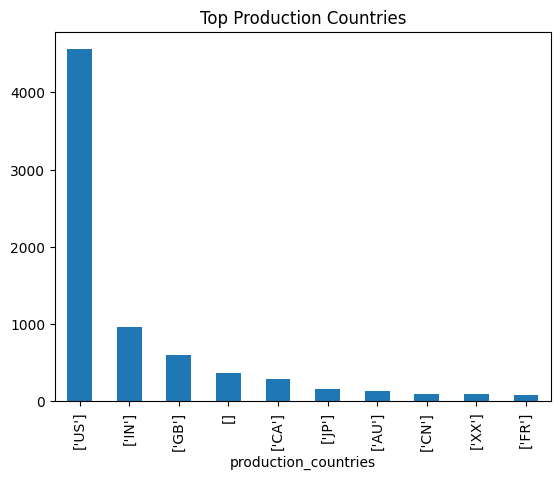

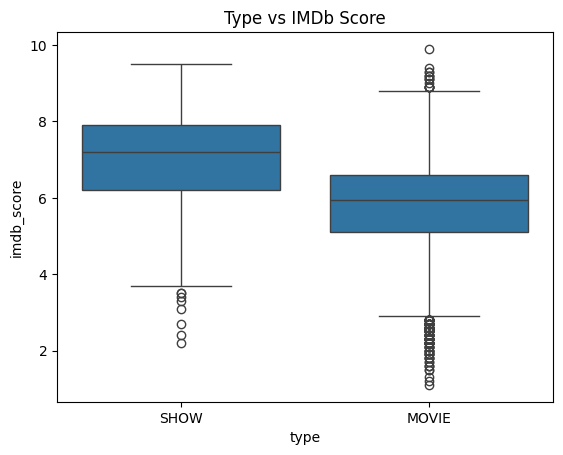

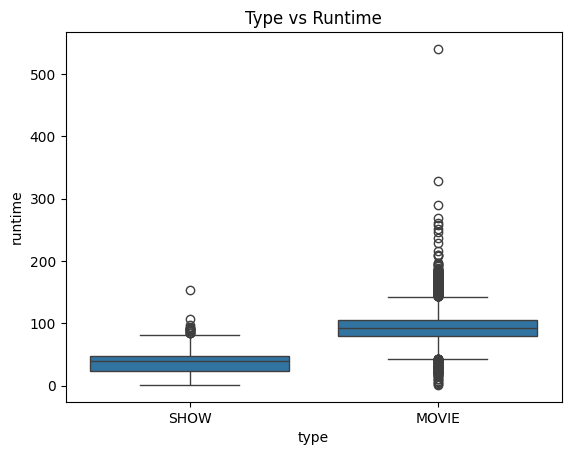

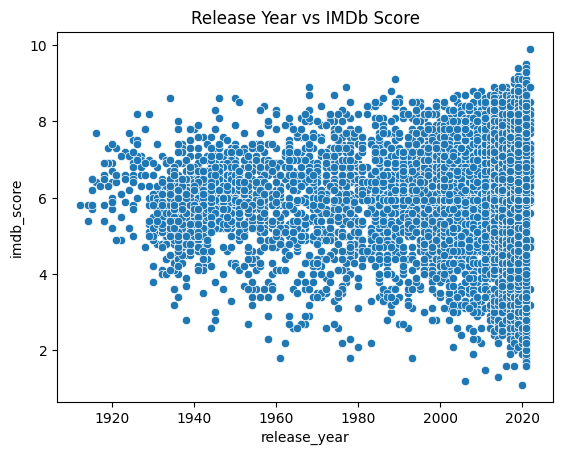

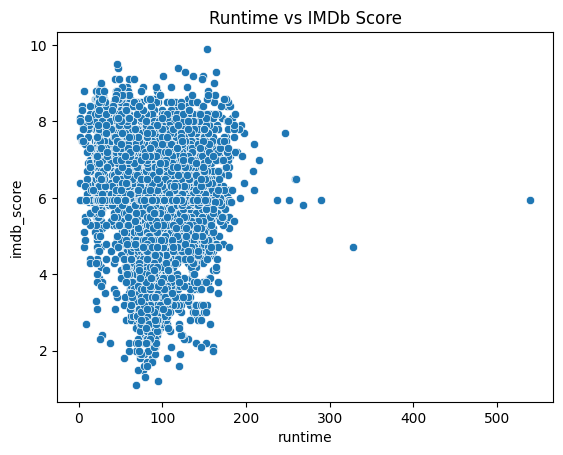

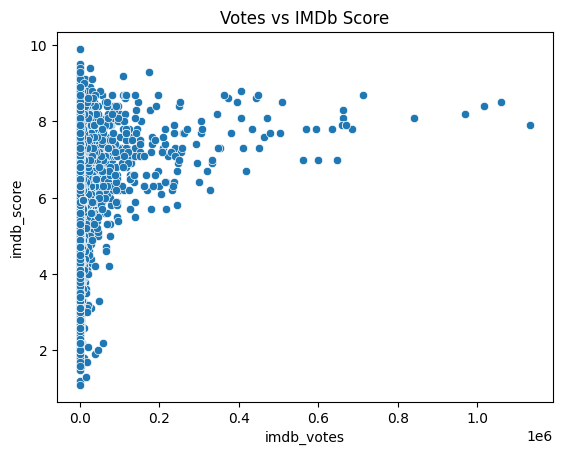

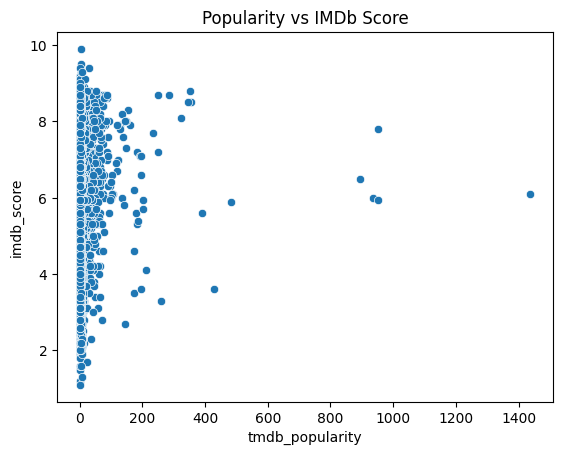

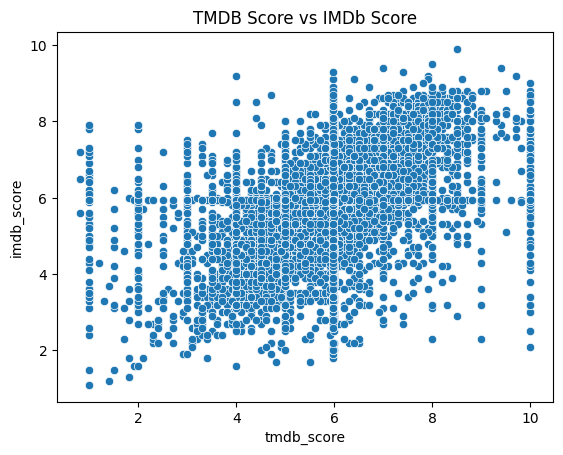

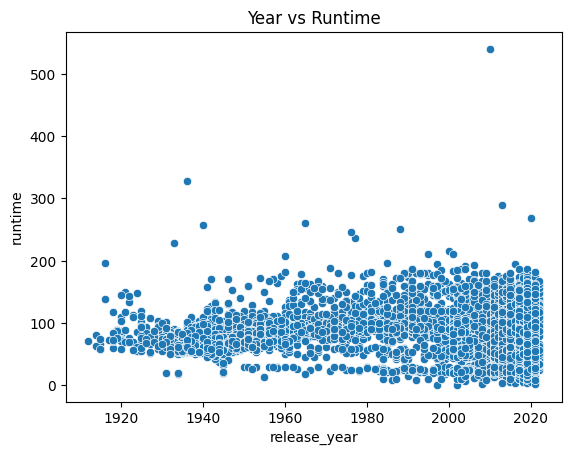

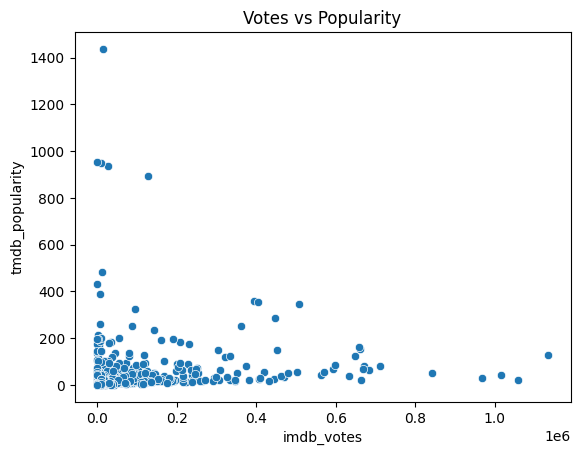

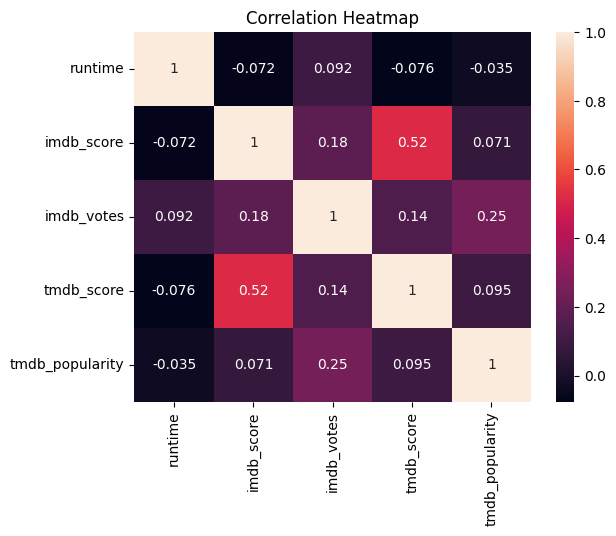

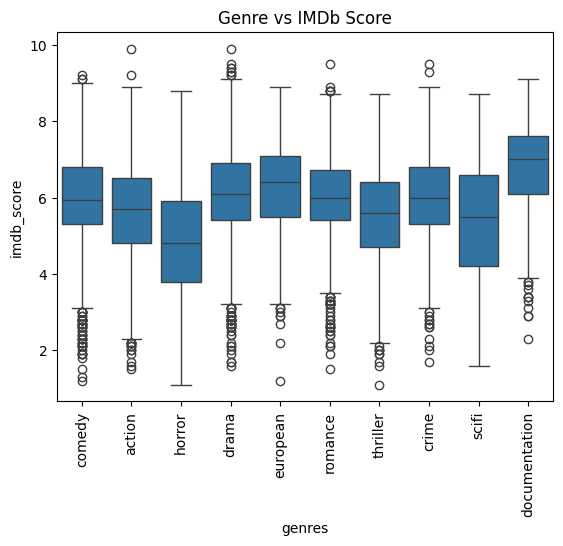

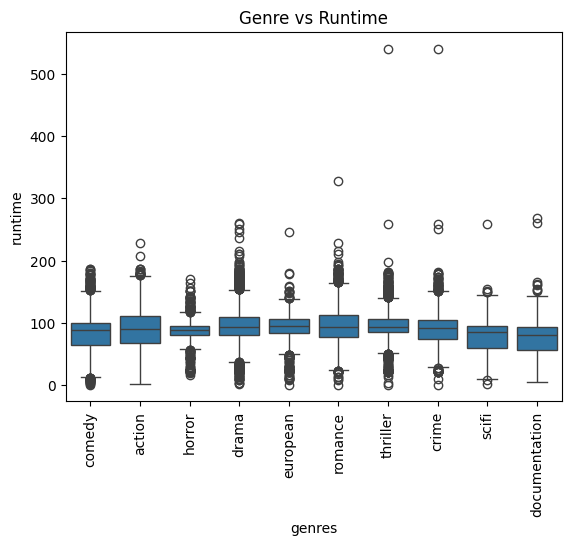

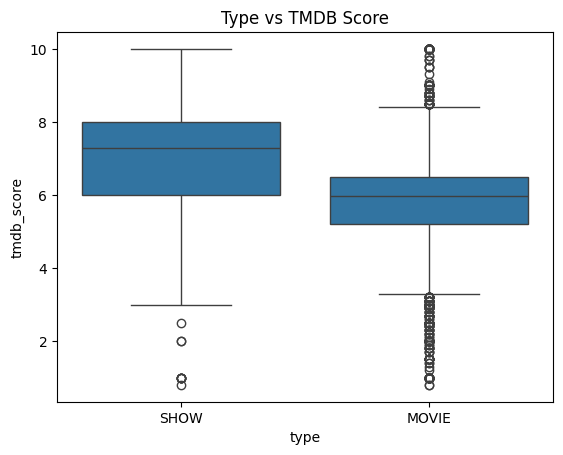

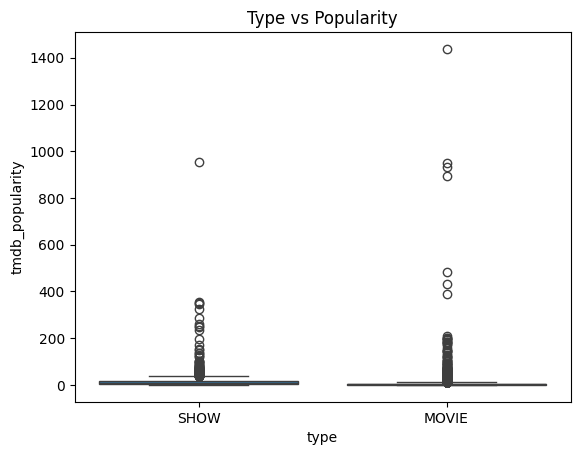

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# fix genres explode issue
genres_df = merged_df.explode('genres').reset_index(drop=True)

# filter top 10 genres for better plots
top_genres = genres_df['genres'].value_counts().head(10).index
filtered_df = genres_df[genres_df['genres'].isin(top_genres)]

# type distribution
plt.figure()
merged_df['type'].value_counts().plot(kind='bar')
plt.title("Movies vs TV Shows")
plt.show()

# release year distribution
plt.figure()
merged_df['release_year'].hist()
plt.title("Release Year Distribution")
plt.show()

# imdb score distribution
plt.figure()
sns.histplot(merged_df['imdb_score'])
plt.title("IMDb Score Distribution")
plt.show()

# runtime distribution
plt.figure()
sns.histplot(merged_df['runtime'])
plt.title("Runtime Distribution")
plt.show()

# tmdb score distribution
plt.figure()
sns.histplot(merged_df['tmdb_score'])
plt.title("TMDB Score Distribution")
plt.show()

# seasons distribution
plt.figure()
sns.histplot(merged_df['seasons'])
plt.title("Seasons Distribution")
plt.show()

# age certification
plt.figure()
merged_df['age_certification'].value_counts().plot(kind='bar')
plt.title("Age Certification")
plt.show()

# imdb votes distribution
plt.figure()
sns.histplot(merged_df['imdb_votes'])
plt.title("IMDb Votes Distribution")
plt.show()

# top genres
plt.figure()
filtered_df['genres'].value_counts().plot(kind='bar')
plt.title("Top Genres")
plt.show()

# top countries
plt.figure()
merged_df['production_countries'].value_counts().head(10).plot(kind='bar')
plt.title("Top Production Countries")
plt.show()

# type vs imdb score
plt.figure()
sns.boxplot(x='type', y='imdb_score', data=merged_df)
plt.title("Type vs IMDb Score")
plt.show()

# type vs runtime
plt.figure()
sns.boxplot(x='type', y='runtime', data=merged_df)
plt.title("Type vs Runtime")
plt.show()

# year vs imdb score
plt.figure()
sns.scatterplot(x='release_year', y='imdb_score', data=merged_df)
plt.title("Release Year vs IMDb Score")
plt.show()

# runtime vs imdb score
plt.figure()
sns.scatterplot(x='runtime', y='imdb_score', data=merged_df)
plt.title("Runtime vs IMDb Score")
plt.show()

# votes vs imdb score
plt.figure()
sns.scatterplot(x='imdb_votes', y='imdb_score', data=merged_df)
plt.title("Votes vs IMDb Score")
plt.show()

# popularity vs imdb score
plt.figure()
sns.scatterplot(x='tmdb_popularity', y='imdb_score', data=merged_df)
plt.title("Popularity vs IMDb Score")
plt.show()

# tmdb score vs imdb score
plt.figure()
sns.scatterplot(x='tmdb_score', y='imdb_score', data=merged_df)
plt.title("TMDB Score vs IMDb Score")
plt.show()

# year vs runtime
plt.figure()
sns.scatterplot(x='release_year', y='runtime', data=merged_df)
plt.title("Year vs Runtime")
plt.show()

# votes vs popularity
plt.figure()
sns.scatterplot(x='imdb_votes', y='tmdb_popularity', data=merged_df)
plt.title("Votes vs Popularity")
plt.show()

# correlation heatmap
plt.figure()
sns.heatmap(merged_df[['runtime','imdb_score','imdb_votes','tmdb_score','tmdb_popularity']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# genre vs imdb score
plt.figure()
sns.boxplot(x='genres', y='imdb_score', data=filtered_df)
plt.xticks(rotation=90)
plt.title("Genre vs IMDb Score")
plt.show()

# genre vs runtime
plt.figure()
sns.boxplot(x='genres', y='runtime', data=filtered_df)
plt.xticks(rotation=90)
plt.title("Genre vs Runtime")
plt.show()

# type vs tmdb score
plt.figure()
sns.boxplot(x='type', y='tmdb_score', data=merged_df)
plt.title("Type vs TMDB Score")
plt.show()

# type vs popularity
plt.figure()
sns.boxplot(x='type', y='tmdb_popularity', data=merged_df)
plt.title("Type vs Popularity")
plt.show()

# SUMMARY:
This project focused on performing Exploratory Data Analysis (EDA) on Amazon Prime Movies and TV Shows data by combining two datasets and transforming them into a structured format. The datasets were merged using a common identifier. Then, extensive preprocessing removed duplicates, handled missing values, and standardized data formats. From a technical standpoint, the analysis used Pandas and NumPy for data manipulation and Matplotlib and Seaborn for visualization. The preprocessing stage ensured data quality by eliminating redundancy and addressing missing values, leading to a clean dataset with a consistent structure.

The exploratory analysis was divided into univariate, bivariate, and multivariate levels to systematically uncover patterns and relationships within the data. More than 20 visualizations were created to examine distributions, correlations, and interactions between variables like release year, ratings, runtime, genres, and popularity.

Several trends and patterns were identified:

- Content production has increased significantly over time, especially after 2000.
- Movies dominate the platform compared to TV shows.
- Drama and Comedy are the most frequently occurring genres.
- Most titles receive moderate IMDb ratings between 5 and 7.
- The United States is the leading contributor to content production.
- There is a positive relationship between IMDb scores and TMDB scores.

Visualization played a key role in turning raw data into understandable insights. By using different types of charts, such as histograms, bar plots, scatter plots, box plots, and heatmaps, relationships between variables were clearly identified and communicated.

# CONCLUSION:

In this project, I successfully conducted an end-to-end exploratory data analysis, starting from raw datasets and moving to meaningful insights. I began by merging two datasets, followed by cleaning and preprocessing to ensure data quality. This step was vital in removing inconsistencies and preparing the data for accurate analysis.

Through systematic exploration and visualization, I identified key patterns and trends within the dataset. The analysis revealed how content is distributed across years, genres, and regions, as well as how different variables like ratings, runtime, and popularity interact with each other.

One of the key takeaways from this project is the importance of data preprocessing, as it directly affects the quality of insights generated. Additionally, visualization proved to be a powerful tool for understanding complex relationships in the data.

Overall, this project improved my understanding of real-world data analysis workflows, including data integration, cleaning, exploration, and interpretation. The insights gained from this analysis can be valuable for decision-making in content production, recommendation systems, and understanding audience preferences.